In [30]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import yaml
import time
import gget
from scipy.stats import zscore
from adjustText import adjust_text

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

import cupy as cp
from cuml.manifold import TSNE
from cuml.decomposition import PCA

sc.settings.verbosity = 3

In [2]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/processed.h5ad"
adata = sc.read_h5ad(fpath)
adata.X = adata.layers['log_norm'].copy()
rsc.get.anndata_to_GPU(adata) # move to GPU
adata

CPU times: user 1.09 s, sys: 3.88 s, total: 4.96 s
Wall time: 10.5 s


AnnData object with n_obs × n_vars = 15867 × 21412
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'batch_colors', 'bbknn_clusters_colors', 'harmony_clusters_colors', 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'rank_genes_grou

# DEG

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:01:02)


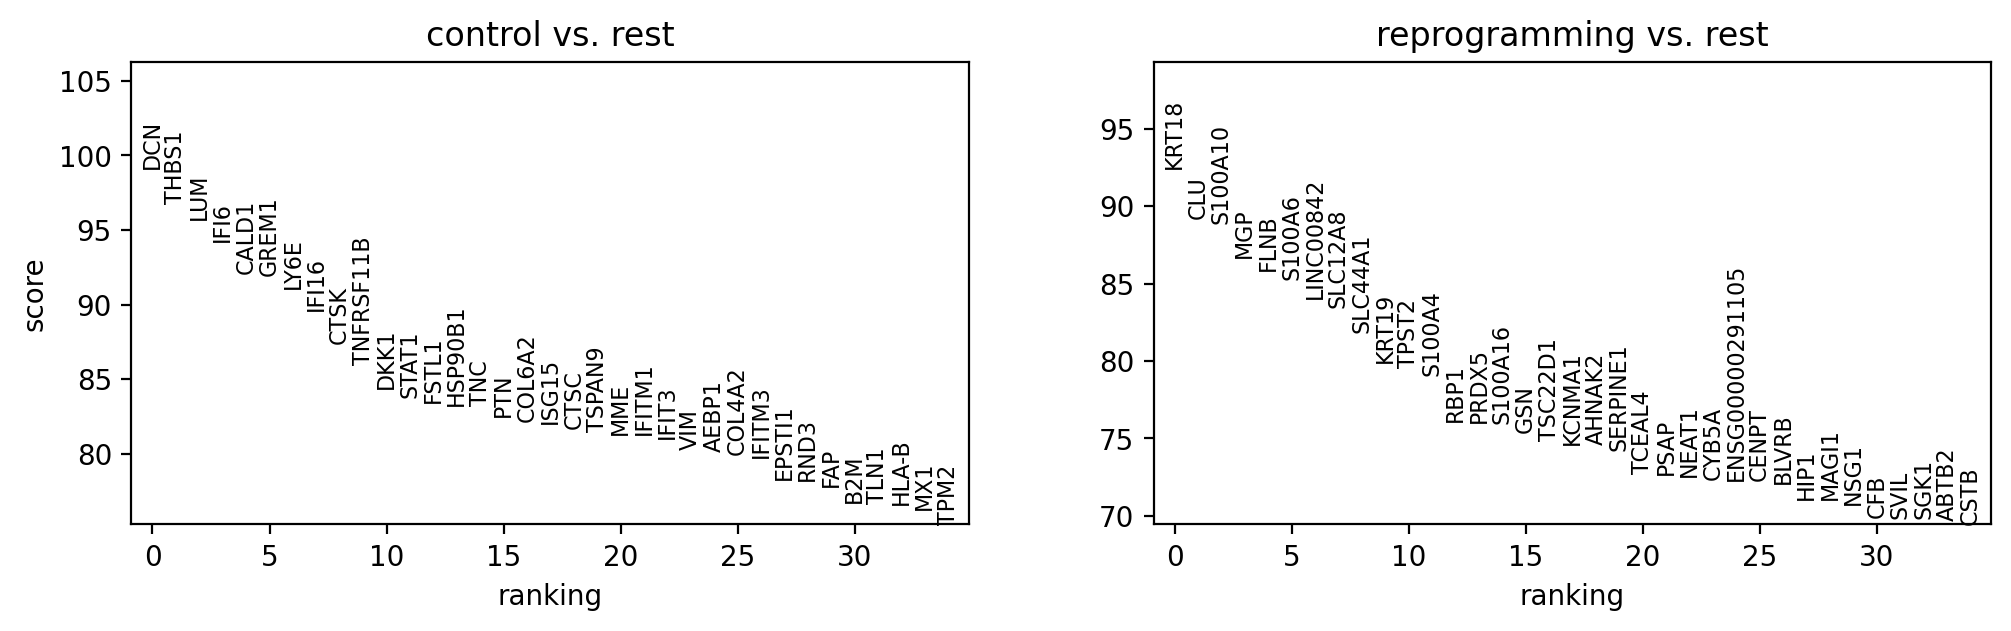

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,control,DCN,99.080986,7.079473,0.0,0.0,0.951788,0.078667
1,control,THBS1,96.784897,6.234342,0.0,0.0,0.945661,0.114701
2,control,LUM,95.664566,6.679245,0.0,0.0,0.921957,0.051091
3,control,IFI6,94.187752,5.505557,0.0,0.0,0.944054,0.432583
4,control,CALD1,92.053505,2.448929,0.0,0.0,0.997991,0.928269


In [3]:
adata.obs['group'] = np.where(adata.obs['cluster_str'].isin(['C2', 'C3']), 'reprogramming', 'control')

sc.tl.rank_genes_groups(
    adata, 
    groupby='group',
    method='wilcoxon',
    layer='log_norm',
    use_raw=False,
    pts=True,
)

deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    pval_cutoff=0.05,
)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 3
sc.pl.rank_genes_groups(
    adata,
    n_genes=35,
    sharey=False,
    ncols=3,
)

deg.head()

In [4]:
def load_pathway(fpath):
    """
    Loads an Enrichr-like database file into a boolean DataFrame.

    Args:
        fpath (str): Path to the Enrichr-like database file.

    Returns:
        pandas.DataFrame: A boolean DataFrame where:
            - Index: Genes
            - Columns: Pathways
            - Values: True if the gene is in the pathway, False otherwise.
    """

    result = []
    with open(fpath,  encoding='utf-8') as f:
        for line in f:
            split_line = [x for x in line.strip().split('\t') if x]  # Remove empty strings directly

            row = {'label': split_line[0]}
            for gene in split_line[1:]:
                row[gene] = 1

            result.append(row)

    df = pd.DataFrame(result)
    df = df.fillna(0.0).set_index('label').astype(bool).T  # Chained operations for clarity

    return df

# Pangloa

In [5]:
fpath = "../../resources/PanglaoDB_Augmented_2021.txt"
marker_mat = load_pathway(fpath)
# filter for certain cell types
cell_types = ['Hematopoietic Stem Cells', 'Endothelial Cells', 'Fibroblasts']

marker_mat = marker_mat[marker_mat[cell_types].any(axis=1)][cell_types]
marker_mat = marker_mat[marker_mat.index.isin(adata.var_names)]

print(f"Raw: {marker_mat.shape=}")
marker_mat.head()


Raw: marker_mat.shape=(421, 3)


label,Hematopoietic Stem Cells,Endothelial Cells,Fibroblasts
RARRES2,False,False,True
CELA1,False,False,True
ANPEP,True,False,False
KLK1,False,True,False
LUM,False,True,True


Hematopoietic Stem Cells
	105 genes


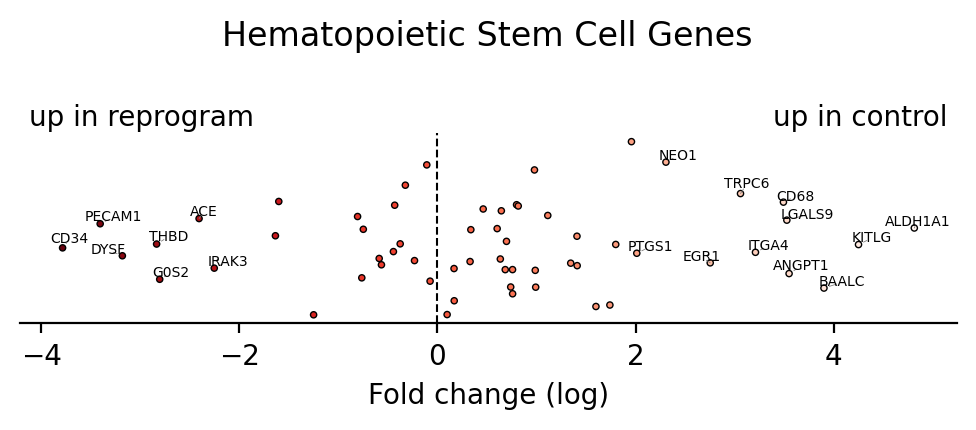

Endothelial Cells
	177 genes


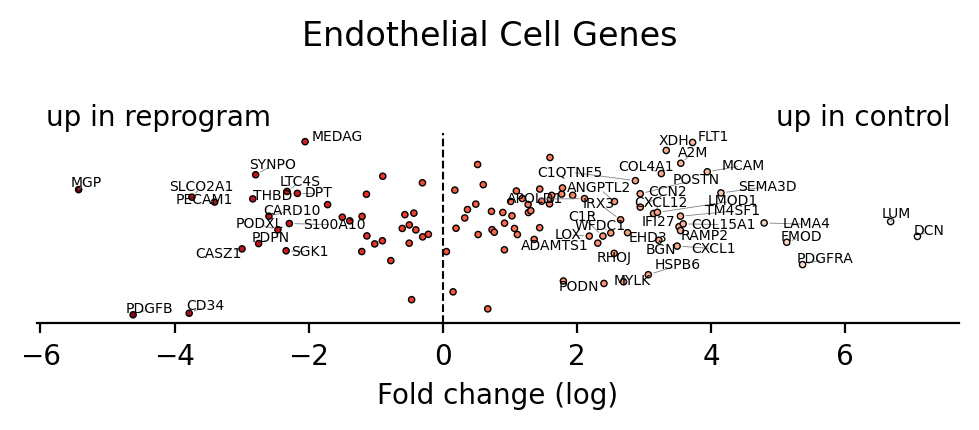

Fibroblasts
	213 genes


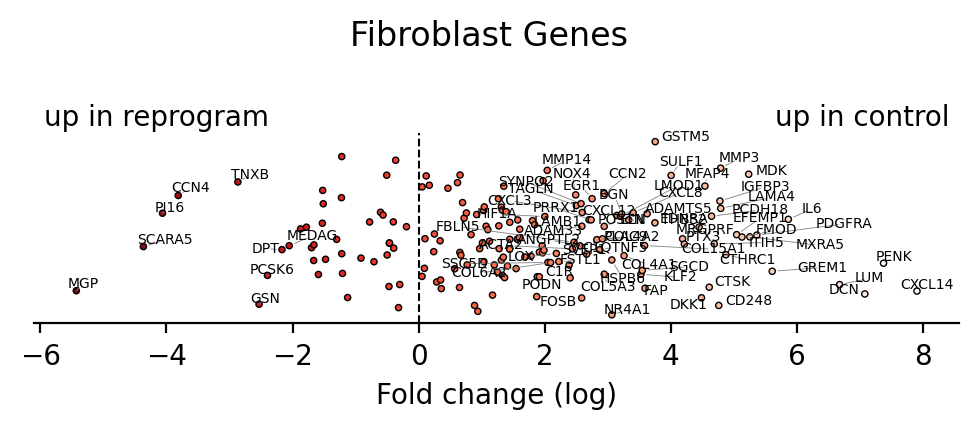

In [82]:
# Define thresholds
max_padj = 0.05

for column in marker_mat:

    gene_list = marker_mat[marker_mat[column]].index
    print(f"{column}")
    print(f"\t{len(gene_list)} genes")

    gdf = deg[deg['names'].isin(gene_list)]
    
    plt.rcParams['figure.dpi'] = 200
    plt.rcParams['figure.figsize'] = 3.5, 1.5
    
    # Sort by fold change
    gdf = gdf.sort_values('logfoldchanges')
    gdf = gdf[gdf['group'] == 'control']
    gdf = gdf[gdf['logfoldchanges'].abs() < 10]

    plt.rcParams['figure.dpi'] = 200
    plt.rcParams['figure.figsize'] = 5, 2
    
    # Manually create jittered y-values
    gdf['y_jitter'] = np.random.normal(loc=0, scale=0.1, size=len(gdf))
    
    # Plot with scatterplot
    plt.figure(figsize=(5, 2), dpi=200)
    ax = sns.scatterplot(
        data=gdf,
        x='logfoldchanges',
        y='y_jitter',
        hue='logfoldchanges',
        palette='Reds_r',
        edgecolor='k',
        linewidth=0.5,
        s=5,
        legend=False,
        zorder=3,
    )
    
    # Annotate genes with large fold changes
    texts = []
    target_x = []
    target_y = []
    for _, row in gdf[abs(gdf['logfoldchanges']) > 2].iterrows():
        texts.append(
            ax.text(
                row['logfoldchanges'],
                row['y_jitter'],
                row['names'],
                fontsize=5,
                ha='center',
                va='bottom',
                zorder=4
            )
        )

        target_x.append(row['logfoldchanges'])
        target_y.append(row['y_jitter'])
    
    
    # Adjust annotations to avoid overlap
    adjust_text(
        texts,
        target_x=target_x,
        target_y=target_y,
        expand_text=(0, 10),     # expand space around text
        # expand_points=(2, 2),   # expand space around points
        avoid_self=True,
        ax=ax,
        arrowprops=dict(arrowstyle='-', lw=0.3, color='gray'),
    )
    
    # Plot formatting
    plt.axvline(x=0, c='k', lw=0.75, ls='--', zorder=0)
    plt.xlabel('Fold change (log)')
    plt.ylabel('')
    plt.yticks([])
    plt.suptitle(f"{column[:-1]} Genes", y=1.05)
    plt.tight_layout()
    sns.despine(left=True)

    ax.text(
        0.01, 1.15, "up in reprogram",
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize=10
    )

    # Top-right
    ax.text(
        0.99, 1.15, "up in control",
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=10
    )
    
    plt.show()
